In [2]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

## visualize data prior to training and testing splitting

In [3]:
df_symbol = pd.read_csv('ASML.csv', index_col='timestamp')[['close']].astype(np.float32)
df_market = pd.read_csv('QQQ.csv', index_col='timestamp')[['close']].astype(np.float32)

display(df_symbol.rename(columns={'close': 'ASML'}).head(2))
display(df_market.rename(columns={'close': 'QQQ'}).head(2))

,ASML
timestamp,
2016-11-25 10:05:00-05:00,103.940002
2016-11-25 10:06:00-05:00,103.980003


,QQQ
timestamp,
2016-11-25 10:03:00-05:00,118.668999
2016-11-25 10:04:00-05:00,118.660004


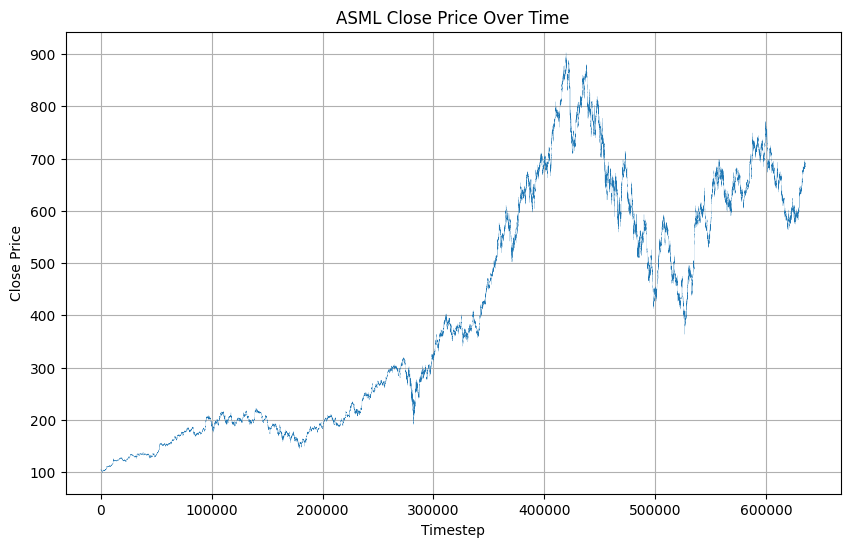

In [4]:
training_data_plot = df_symbol.reset_index().plot(y='close', figsize=(10, 6), title='ASML Close Price Over Time', linewidth=0.1, legend=False, grid=True).set(xlabel='Timestep', ylabel='Close Price')

## benchmark against buy-and-hold and market's performance

In [5]:
def standardize_returns_from_prices(prices):
    returns = prices.pct_change()
    returns += 1
    returns.iloc[0] = 1 # set first day pseudo-price
    return returns.cumprod()

def sharpe_ratio(returns, risk_free_rate=0):
    adjusted_returns = returns - risk_free_rate
    mean_returns = adjusted_returns.mean()
    std_returns = adjusted_returns.std()
    if std_returns != 0:
        sharpe_ratio = mean_returns/std_returns
    else:
        sharpe_ratio = np.nan
    return sharpe_ratio

def maximum_drawdown(portfolio_values):
    rolling_max = portfolio_values.cummax()
    drawdown = (portfolio_values - rolling_max)/rolling_max
    max_drawdown = drawdown.min()
    return max_drawdown

def format_model_description(filename):
    parts = filename.split('_')
    model_type = parts[0]
    train_iter = int(parts[1])
    batch_size = int(parts[4])
    num_indicators = int(parts[7])
    reward_shaped = int(parts[10])
    leverage_option = parts[13] == 'True'
    description = f'{model_type} {(train_iter * batch_size):,} timesteps with {num_indicators} indicators'
    if leverage_option:
        description += ', leverage'
    if reward_shaped:
        description += ', and custom-shaped reward'
    return train_iter, num_indicators, reward_shaped, leverage_option, description

In [6]:
pd.read_csv('inferences/PPO_100_train_iter_1000_batch_size_0_tech_indicators_0_reward_option_False_leverage_option.csv', index_col='timestamp')

,time_index,portfolio_value,cash_balance,profit,asset_price,order_size,borrow_size,leverage_size,margin_interest,asset_position
timestamp,,,,,,,,,,
2022-08-08 10:05:00-05:00,1,1000000.0,1000000.0,0.0,1146.90,0,0,0,0,0
2022-08-08 10:06:00-05:00,2,1000000.0,1000000.0,0.0,1148.08,0,0,0,0,0
2022-08-08 10:07:00-05:00,3,1000000.0,1000000.0,0.0,1147.22,0,0,0,0,0
2022-08-08 10:08:00-05:00,4,1000000.0,1000000.0,0.0,1146.00,0,0,0,0,0
2022-08-08 10:09:00-05:00,5,1000000.0,1000000.0,0.0,1144.59,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
2023-11-24 12:59:00-05:00,127130,1000000.0,1000000.0,0.0,1382.12,0,0,0,0,0
2023-11-24 13:00:00-05:00,127131,1000000.0,1000000.0,0.0,1382.36,0,0,0,0,0
2023-11-24 13:07:00-05:00,127132,1000000.0,1000000.0,0.0,1383.40,0,0,0,0,0


PPO_100_train_iter_1000_batch_size_11_tech_indicators_2_reward_option_True_leverage_option.csv
Short positions' PnL       : 123387.36
Short positions' occurrence: 1309
No positions' PnL          : -1394960.95
Long positions' PnL        : 1331294.79
Long positions' occurrence : 4749
Total PnL                  : 122844.20
Sharpe ratio               : 0.001
Maximum drawdown           : -0.353


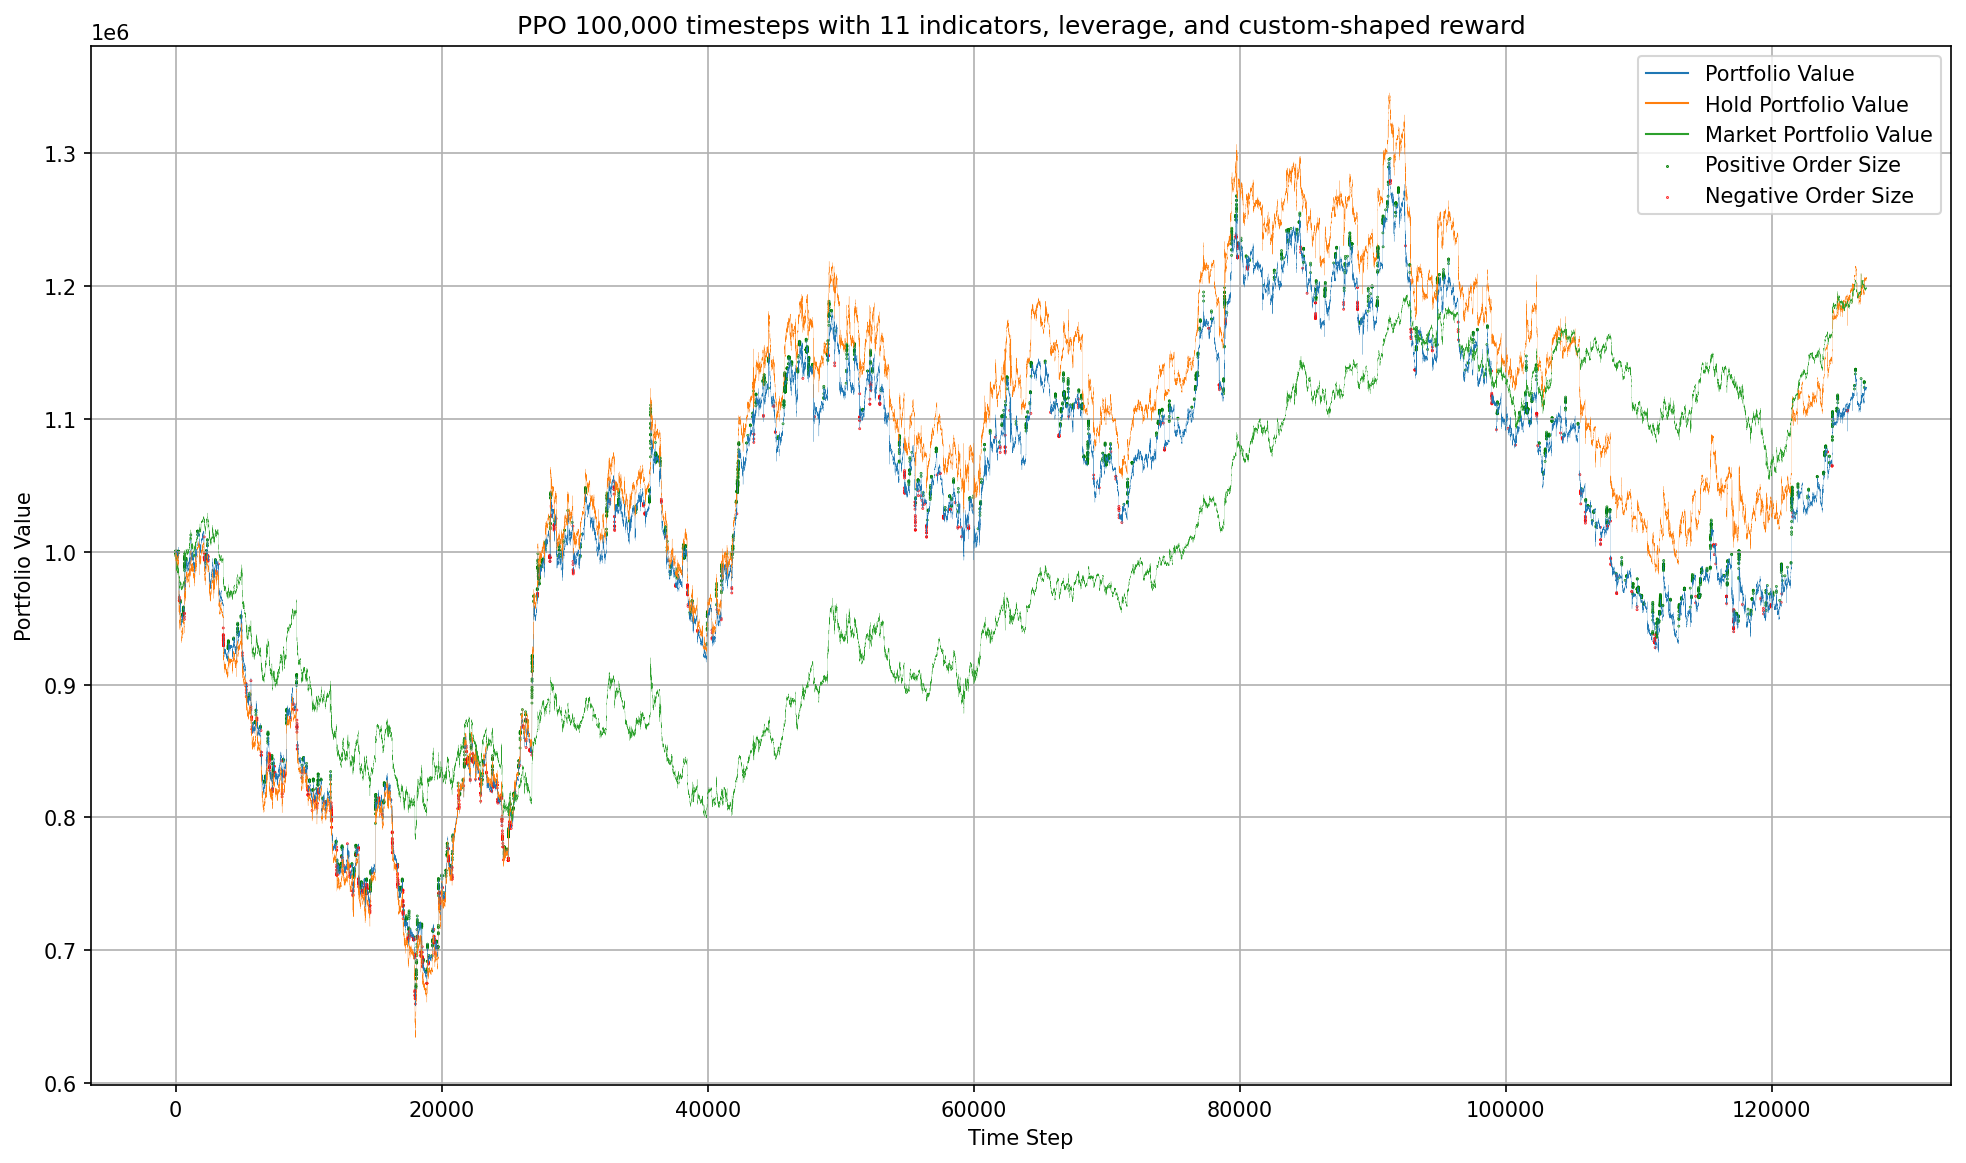

In [57]:
PPO_inference_result_paths = glob.glob(os.path.join('inferences', 'PPO*.csv'))
SAC_inference_result_paths = glob.glob(os.path.join('inferences', 'SAC*.csv'))
df_hold_portfolio = df_symbol['close'].rename('hold_portfolio_value')
df_market_portfolio = df_market['close'].rename('market_portfolio_value')

for inference_result_path in PPO_inference_result_paths + SAC_inference_result_paths:
    model_name = os.path.basename(inference_result_path)
    train_iter, num_indicators, reward_shaped, leverage_option, description = format_model_description(model_name)
    if train_iter == 100 and num_indicators==11 and reward_shaped==2 and leverage_option is True: # filter logic to filter the results
#     if train_iter == 500 and reward_shaped == 0: # filter logic to filter the results
        print(model_name)
        
        df_portfolio = pd.read_csv(inference_result_path, index_col='timestamp')
        df = pd.concat([df_portfolio, df_hold_portfolio, df_market_portfolio], join='inner', axis=1)
        df['hold_portfolio_value'] = standardize_returns_from_prices(df['hold_portfolio_value'])*1e6
        df['market_portfolio_value'] = standardize_returns_from_prices(df['market_portfolio_value'])*1e6
        
        short_orders = df[df['order_size'] < 0]
        no_orders = df[df['order_size'] == 0]
        long_orders = df[df['order_size'] > 0]

        print(f"Short positions' PnL       : {short_orders['profit'].sum():.2f}")
        print(f"Short positions' occurrence: {short_orders.shape[0]}")
        print(f"No positions' PnL          : {no_orders['profit'].sum():.2f}")
        print(f"Long positions' PnL        : {long_orders['profit'].sum():.2f}")
        print(f"Long positions' occurrence : {long_orders.shape[0]}")
        print(f"Total PnL                  : {df_portfolio['profit'].sum():.2f}")
        print(f"Sharpe ratio               : {sharpe_ratio(df_portfolio['portfolio_value'].pct_change()):.3f}")
        print(f"Maximum drawdown           : {maximum_drawdown(df_portfolio['portfolio_value']):.3f}")

        fig, ax = plt.subplots(figsize=(16, 9), dpi=150)
        ax.plot(df['time_index'], df['portfolio_value'].values, label='Portfolio Value', linewidth=0.1)
        ax.plot(df['time_index'], df['hold_portfolio_value'].values, label='Hold Portfolio Value', linewidth=0.1)
        ax.plot(df['time_index'], df['market_portfolio_value'].values, label='Market Portfolio Value', linewidth=0.1)

        def scale_marker_size(order_size):
                return np.sqrt(abs(order_size))*0.05

        ax.scatter(long_orders['time_index'], long_orders['portfolio_value'], 
                color='green', s=scale_marker_size(long_orders['order_size']), label='Positive Order Size')
        ax.scatter(short_orders['time_index'], short_orders['portfolio_value'], 
                color='red', s=scale_marker_size(short_orders['order_size']), label='Negative Order Size')

        ax.set(title=f'{description}', xlabel='Time Step', ylabel='Portfolio Value')
        ax.grid(True)

        handles, labels = ax.get_legend_handles_labels()
        handles[0] = mlines.Line2D([], [], color='#1f77b4', linewidth=1, label='Portfolio Value')
        handles[1] = mlines.Line2D([], [], color='#ff7f0e', linewidth=1, label='Hold Portfolio Value')
        handles[2] = mlines.Line2D([], [], color='#2ca02c', linewidth=1, label='Market Portfolio Value')
        ax.legend(handles=handles, labels=labels)
        plt.show()

In [55]:
display(short_orders.head())
display(long_orders.head())
print(f"total short orders: {sum(short_orders['order_size'])}")
print(f"total long orders : {sum(long_orders['order_size'])}")

,time_index,portfolio_value,cash_balance,profit,asset_price,order_size,borrow_size,leverage_size,margin_interest,asset_position,hold_portfolio_value,market_portfolio_value
timestamp,,,,,,,,,,,,
2022-08-08 10:35:00-05:00,30,999933.87,981600.75,-31.45,1145.82,-15,0,0,0.0,16,999058.3750,995137.0000
2022-08-08 11:18:00-05:00,63,999279.19,941547.19,-89.23,1132.00,-4,0,0,0.0,51,987008.5000,986119.0625
2022-08-08 11:20:00-05:00,65,999217.55,946066.18,-45.33,1130.88,-4,0,0,0.0,47,986031.9375,986534.5000
2022-08-08 11:22:00-05:00,67,999360.59,950597.73,70.19,1134.02,-4,0,0,0.0,43,988769.8125,987350.2500
2022-08-08 11:30:00-05:00,75,999218.62,956246.32,30.03,1130.85,-5,0,0,0.0,38,986005.8125,986490.8750


,time_index,portfolio_value,cash_balance,profit,asset_price,order_size,borrow_size,leverage_size,margin_interest,asset_position,hold_portfolio_value,market_portfolio_value
timestamp,,,,,,,,,,,,
2022-08-08 10:06:00-05:00,2,999991.96,991955.40,-8.04,1148.08,7,0,0,0.0,7,1.001029e+06,999569.1250
2022-08-08 10:07:00-05:00,3,999976.77,982768.47,-15.20,1147.22,8,0,0,0.0,15,1.000279e+06,999045.8750
2022-08-08 10:08:00-05:00,4,999950.44,974738.44,-26.32,1146.00,7,0,0,0.0,22,9.992152e+05,998645.6875
2022-08-08 10:09:00-05:00,5,999913.70,969009.77,-36.74,1144.59,5,0,0,0.0,27,9.979858e+05,998922.6875
2022-08-08 10:10:00-05:00,6,999883.48,964430.64,-30.22,1143.64,4,0,0,0.0,31,9.971575e+05,998706.9375


total short orders: -64164
total long orders : 62357


## examine training process

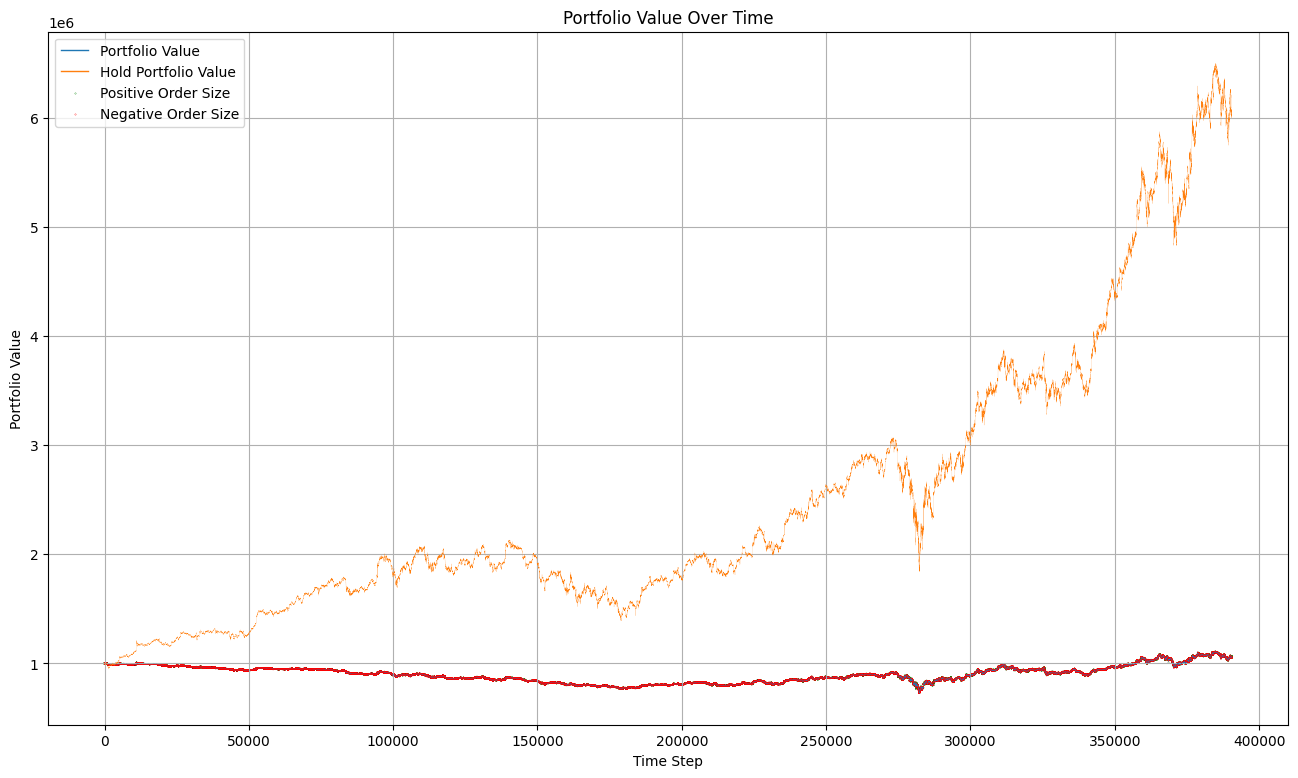

In [95]:
df_training_portfolio = pd.read_csv('logs/episode_1.csv', index_col='timestamp')
training_long_orders = df_training_portfolio[df_training_portfolio['order_size'] > 0]
training_short_orders = df_training_portfolio[df_training_portfolio['order_size'] < 0]
df = pd.concat([df_training_portfolio, df_hold_portfolio], join='inner', axis=1)
df['hold_portfolio_value'] = standardize_returns_from_prices(df['hold_portfolio_value'])*1e6

fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
ax.plot(df['time_index'], df['portfolio_value'].values, label='Portfolio Value', linewidth=0.1)
ax.plot(df['time_index'], df['hold_portfolio_value'].values, label='Hold Portfolio Value', linewidth=0.1)

def scale_marker_size(order_size):
    return np.sqrt(abs(order_size))*0.01

ax.scatter(training_long_orders['time_index'], training_long_orders['portfolio_value'], 
           color='green', s=scale_marker_size(training_long_orders['order_size']), label='Positive Order Size')
ax.scatter(training_short_orders['time_index'], training_short_orders['portfolio_value'], 
           color='red', s=scale_marker_size(training_short_orders['order_size']), label='Negative Order Size')

ax.set(title='Portfolio Value Over Time', xlabel='Time Step', ylabel='Portfolio Value')
ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
handles[0] = mlines.Line2D([], [], color='#1f77b4', linewidth=1, label='Portfolio Value')
handles[1] = mlines.Line2D([], [], color='#ff7f0e', linewidth=1, label='Hold Portfolio Value')
ax.legend(handles=handles, labels=labels)
plt.show()